[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yzyouzhang/dafx2026-hrtf-tutorial/blob/main/02_niirf_filter_field.ipynb)

<!-- TODO: "main" is a placeholder branch -- re-point to a release tag (e.g. v1.0-dafx26) closer to the tutorial date -->


In [ ]:
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import os

    REPO_NAME = "dafx2026-hrtf-tutorial"
    REPO_URL = "https://github.com/yzyouzhang/dafx2026-hrtf-tutorial.git"
    BRANCH = "main"  # TODO: placeholder branch -- re-point to a release tag (e.g. v1.0-dafx26) closer to the tutorial date

    if os.path.basename(os.getcwd()) != REPO_NAME:
        if not os.path.isdir(REPO_NAME):
            !git clone -b {BRANCH} {REPO_URL}
        %cd {REPO_NAME}

    if os.path.exists("requirements.txt"):
        !pip install -q -r requirements.txt
    else:
        print("WARNING: requirements.txt not found at repo root -- dependencies were not installed; install manually.")

# 02 — NIIRF: Neural IIR Filter Field (Differentiable DSP for HRTF)

**DAFx 2026 Tutorial: From Neural Fields to Personalized Spatial Audio**
Neil Zhang & Yoshiki Masuyama

In `01_minimal_neural_field.ipynb`, the neural field outputs raw magnitude spectrum bins directly. **NIIRF** ([Masuyama, Wichern, Germain, Pan, Khurana, Hori, Le Roux, ICASSP 2024](https://github.com/merlresearch/neural-IIR-field)) predicts the parameters of *a cascade of IIR filters* — a low-shelf filter, $K$ peaking filters, and a high-shelf filter — and reconstructs the magnitude response from those parameters with a fully differentiable DSP module. This enables end-to-end training of the neural field through the parametric IIR filters, in the same spirit as differentiable biquads and differentiable audio effects.

**DSP-regularized modeling:** The parametric IIR filters are suitable for capturing the modal (peak-and-notch) structures of HRTFs. The filter parameters are interpretable — **center/cut frequency, gain, bandwidth** — in place of the raw magnitude bins in notebook 01. The modeling capability is bounded by what the $K+2$ IIR filters can express.

This notebook covers the **single-subject** field only: direction in, filter parameters out. There is no latent code and no subject split.

1. The differentiable filter cascade is copied from [the official NIIRF repository](https://github.com/merlresearch/neural-IIR-field) (see `src/iir_downstream.py`).
2. The network follows the **SIREN backbone as in notebook 01** — only the meaning of its output changes, from magnitude bins to filter parameters.
3. The hyperparameters are updated for SONICOM and for the SIREN-based architecture.


## 0. Setup

In [17]:
import os
import copy
import random

import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from src.data import load_real_sonicom

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SOFA_DIR = "data/sonicom"

# Copied from the official configuration for the HUTUBS dataset
CENTER_FCS = [100, 732, 1206, 1680, 2153, 2799, 3575, 4005, 4565, 5469, 6331, 7106, 7752, 8441, 9130, 9776, 10379, 11025, 11671, 12317, 12920, 13566, 14126, 14470, 14901, 15159, 15805, 16408, 17054, 17743, 18389, 19035, 19638, 22000]

cfg = dict(
    subject_index=0,
    n_layers=4,
    hidden_dim=512,
    w0=30.0,
    n_peaking_filters=32,
    fcs=CENTER_FCS,
    nfft=512,
    eps=1e-3,
    loss_scale=0.1,
    n_epochs=500,
    batch_size=16,
    lr=1e-4,
    weight_decay=1e-6,
    clip=10.0,
    n_train_dirs=100,
    n_dev_dirs=50,
)
cfg["n_freq_bins"] = cfg["nfft"] // 2 + 1
print(f"Config: {cfg}")


Using device: cuda
Config: {'subject_index': 0, 'n_layers': 4, 'hidden_dim': 512, 'w0': 30.0, 'n_peaking_filters': 32, 'fcs': [100, 732, 1206, 1680, 2153, 2799, 3575, 4005, 4565, 5469, 6331, 7106, 7752, 8441, 9130, 9776, 10379, 11025, 11671, 12317, 12920, 13566, 14126, 14470, 14901, 15159, 15805, 16408, 17054, 17743, 18389, 19035, 19638, 22000], 'nfft': 512, 'eps': 0.001, 'loss_scale': 0.1, 'n_epochs': 500, 'batch_size': 16, 'lr': 0.0001, 'weight_decay': 1e-06, 'clip': 10.0, 'n_train_dirs': 100, 'n_dev_dirs': 50, 'n_freq_bins': 257}


## 1. Load data (one subject, the same loader as in notebook 01)


In [18]:
subject_id = f"p{cfg['subject_index'] + 1:04d}"
hrir, positions, fs = load_real_sonicom(os.path.join(SOFA_DIR, f"{subject_id}.sofa"))
fs = float(fs)

print(f"Subject {subject_id}: hrir {hrir.shape} (directions, ears, taps), fs = {fs:.0f} Hz")


SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
Subject p0001: hrir (828, 2, 256) (directions, ears, taps), fs = 48000 Hz


## 2. Preprocess: target spectra, direction encoding, direction split

There are two differences from notebook 01:

- **No normalization:** Notebook 01 normalizes the target spectra, but we do not do so here. NIIRF predicts the parameters of a cascade of IIR filters, and these filters are designed to capture the spectral peaks and notches of the original spectra.
- **Split over directions:** The task is to recover the full set of HRTF measurements from a sparse subset. NIIRF is trained on the support directions and tested on unseen directions.


In [19]:
def get_log_mag_torch(x, nfft, eps=1e-3):
    return 20.0 * torch.log10(torch.abs(torch.fft.rfft(x, nfft)) + eps)

In [20]:
n_dir = hrir.shape[0]
hrir_t = torch.tensor(hrir, dtype=torch.float32, device=device)
target_db = get_log_mag_torch(hrir_t, nfft=cfg["nfft"], eps=cfg["eps"])
freqs_hz = np.fft.rfftfreq(cfg["nfft"], d=1 / fs)

dir_feats = np.stack([
    np.deg2rad(positions[:, 0]) / np.pi,
    np.deg2rad(positions[:, 1]) / np.pi,
], axis=-1).astype(np.float32)
dir_feats_t = torch.tensor(dir_feats, device=device)
print("dir_feats:", tuple(dir_feats_t.shape), " target (dB):", tuple(target_db.shape))

dir_feats: (828, 2)  target (dB): (828, 2, 257)


In [21]:
perm = np.random.default_rng(0).permutation(n_dir)
train_dir_idx = perm[:cfg["n_train_dirs"]]
dev_dir_idx = perm[cfg["n_train_dirs"]:cfg["n_train_dirs"] + cfg["n_dev_dirs"]]
test_dir_idx = perm[cfg["n_train_dirs"] + cfg["n_dev_dirs"]:]
print(f"{len(train_dir_idx)} train / {len(dev_dir_idx)} dev / {len(test_dir_idx)} test directions")

100 train / 50 dev / 678 test directions


## 3. Differentiable IIR cascade and parameter squashing

`src/iir_downstream.py` is copied from the official repository, supporting a cascade of one low-shelf, $K$ peaking filters, and one high-shelf. It evaluates each filter's log-magnitude and sums them up as the cascade is a product of transfer functions, so in the log domain it becomes an addition. Computing filter response with unbounded network outputs would easily get trapped in local optima, so the squashing below is essential:

- **`fc`** — a per-filter sigmoid into $[f_{c,\text{low}}, f_{c,\text{high}}]$. Adjacent filters have overlapping ranges and can trade off which spectral feature they claim. The two shelf filters get the fixed ranges $[20, 200]$ Hz and $[16000, 23000]$ Hz.
- **`fb`** — a sigmoid into $[100, 4000]$ Hz, shared by every peak.
- **`gain`** — left completely unbounded and interpreted directly as dB.

One subtlety about the shapes is worth noting: there are $K + 2$ gains and $K + 2$ center frequencies (2 cut frequencies for the shelf filters), but only $K$ bandwidths, because shelf filters do not have bandwidth. The network therefore emits $3K + 4$ numbers per ear (100 for $K = 32$), not $3(K+2)$, and `HRTF_IIR` internally pads `fb` with a zero at each end for the two shelf filters to consume and discard.

In [22]:
from src.iir_downstream import HRTF_IIR

LFS_FC_LIMITS, HFS_FC_LIMITS, FB_LIMITS = (20, 200), (16000, 23000), (100, 4000)  # HFS filter's range is increased to 23 kHz for the sampling rate of 48 kHz
K = cfg["n_peaking_filters"]
n_params_per_ear = 3 * K + 4  # (K+2) gains + (K+2) center freqs + K bandwidths

fcs = cfg["fcs"]
fc_limits = [(fcs[n - 1], fcs[n + 1]) for n in range(1, len(fcs) - 1)]
assert len(fc_limits) == K, f"{len(fcs)} center frequencies imply {len(fc_limits)} peaks, but K={K}"

fc_low = torch.tensor([LFS_FC_LIMITS[0]] + [lo for lo, _ in fc_limits] + [HFS_FC_LIMITS[0]],
                      dtype=torch.float32, device=device)
fc_width = torch.tensor([LFS_FC_LIMITS[1] - LFS_FC_LIMITS[0]] + [hi - lo for lo, hi in fc_limits]
                        + [HFS_FC_LIMITS[1] - HFS_FC_LIMITS[0]], dtype=torch.float32, device=device)
fb_low, fb_width = FB_LIMITS[0], FB_LIMITS[1] - FB_LIMITS[0]

render = HRTF_IIR(npeaks=K, fs=fs)


def squash_params(raw):
    """[batch, 2*n_params_per_ear] -> gain [batch, 2, K+2], fc [batch, 2, K+2], fb [batch, 2, K]."""
    gain, fc, fb = torch.split(raw.reshape(-1, 2, n_params_per_ear), K + 2, dim=-1)
    fc = fc_width * torch.sigmoid(fc) + fc_low
    fb = fb_width * torch.sigmoid(fb) + fb_low
    return gain, fc, fb


## 4. SIREN field predicting filter parameters (not raw magnitude)

The network follows the **SIREN architecture used in notebook 01** — the same layer type, $\omega_0$, and direction encoding. The last layer is modified to emit `2 * n_params_per_ear` parameters, which are converted to filter parameters through `squash_params` and passed to DDSP module to compute magnitude spectra.

(The official NIIRF uses frozen random Fourier features, MLPs with GELU activation and dropout rather than a SIREN. Here, we retain SIREN from Notebook 01 to emphasize the difference between HRTF field and NIIRF.)


In [23]:
class SirenLayer(nn.Module):
    def __init__(self, in_f, out_f, w0=30.0, is_first=False, is_last=False):
        super().__init__()
        self.w0 = w0
        self.linear = nn.Linear(in_f, out_f)
        self.is_last = is_last
        b = 1 / in_f if is_first else np.sqrt(6 / in_f) / w0
        with torch.no_grad():
            self.linear.weight.uniform_(-b, b)

    def forward(self, x):
        x = self.linear(x)
        return x if self.is_last else torch.sin(self.w0 * x)


def build_siren(dims, w0):
    layers = [SirenLayer(dims[0], dims[1], w0=w0, is_first=True)]
    for d0, d1 in zip(dims[1:-2], dims[2:-1]):
        layers.append(SirenLayer(d0, d1, w0=w0))
    layers.append(SirenLayer(dims[-2], dims[-1], w0=w0, is_last=True))
    return nn.Sequential(*layers)


dims = [2] + [cfg["hidden_dim"] for _ in range(cfg["n_layers"] - 1)] + [2 * n_params_per_ear]
field = build_siren(dims, cfg["w0"]).to(device)


def predict_and_rendering(dirs):
    """Directions [batch, 2] -> reconstructed magnitude spectrum [batch, 2, n_freq_bins] in dB."""
    gain, fc, fb = squash_params(field(dirs))
    return render.get_log_mag(gain, fc, fb, nfft=cfg["nfft"], eps=cfg["eps"])


n_params_field = sum(p.numel() for p in field.parameters())
print(f"Field parameters: {n_params_field:,} -> {n_params_per_ear} filter parameters per ear per direction")


Field parameters: 629,448 -> 100 filter parameters per ear per direction


## 5. Train on the sparse set of measured directions


Training NIIRF field: 100%|██████████| 500/500 [04:22<00:00,  1.91it/s, dev_loss=5.11, loss=2.6] 


Restored checkpoint from epoch 409 (best dev loss = 3.2794)


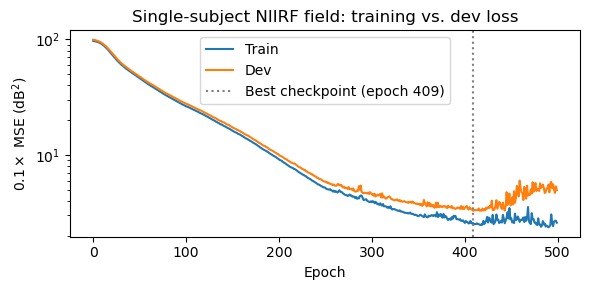

In [24]:
def batch_loss(idx):
    return cfg["loss_scale"] * nn.functional.mse_loss(predict_and_rendering(dir_feats_t[idx]), target_db[idx])


optimizer = torch.optim.RAdam(field.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
rng = np.random.default_rng(0)

train_losses, dev_losses = [], []
best_dev, best_epoch, best_state = float("inf"), None, None

pbar = tqdm(range(cfg["n_epochs"]), desc="Training NIIRF field")
for epoch in pbar:
    epoch_loss = 0.0
    shuffled = rng.permutation(train_dir_idx)
    batches = np.array_split(shuffled, max(1, len(shuffled) // cfg["batch_size"]))
    for batch in batches:
        loss = batch_loss(batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(field.parameters(), max_norm=cfg["clip"])
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(batches))

    with torch.no_grad():
        dev_losses.append(batch_loss(dev_dir_idx).item())

    if dev_losses[-1] < best_dev:
        best_dev, best_epoch = dev_losses[-1], epoch
        best_state = copy.deepcopy(field.state_dict())

    if epoch % max(1, cfg["n_epochs"] // 20) == 0:
        pbar.set_postfix(loss=train_losses[-1], dev_loss=dev_losses[-1])

field.load_state_dict(best_state)
print(f"Restored checkpoint from epoch {best_epoch} (best dev loss = {best_dev:.4f})")

plt.figure(figsize=(6, 3))
plt.plot(train_losses, label="Train")
plt.plot(dev_losses, label="Dev")
plt.axvline(best_epoch, color="gray", linestyle=":", label=f"Best checkpoint (epoch {best_epoch})")
plt.xlabel("Epoch"); plt.ylabel(r"$0.1 \times$ MSE (dB$^2$)"); plt.yscale("log")
plt.title("Single-subject NIIRF field: training vs. dev loss")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Evaluate: log-spectral distortion on held-out directions

Following the official `stage3b_evaluate_niirf.py`, the LSD is band-limited to 20 Hz – 20 kHz before taking the RMS. Bins outside that range are dominated by the `eps` floor and by the measurement noise of the HRIRs themselves, so including them would mostly measure how well the model fits noise.


In [25]:
fwidth = fs / cfg["nfft"]
low_idx, high_idx = int(np.ceil(20 / fwidth)), int(np.ceil(20000 / fwidth))
band = slice(low_idx, high_idx + 1)

def evaluate(idx, label, band):
    with torch.no_grad():
        pred_db = predict_and_rendering(dir_feats_t[idx])
    lsd = torch.sqrt(torch.mean((target_db[idx][..., band] - pred_db[..., band]) ** 2, dim=-1))
    print(f"{label}: mean LSD = {lsd.mean():.2f} dB over {len(idx)} direction(s)")
    return lsd.cpu().numpy()


print(f"LSD band: bins {low_idx}-{high_idx} ({freqs_hz[low_idx]:.0f}-{freqs_hz[high_idx]:.0f} Hz)")
train_lsd = evaluate(train_dir_idx, "Train directions", band)
dev_lsd = evaluate(dev_dir_idx, "Dev directions", band)
test_lsd = evaluate(test_dir_idx, "Test directions (held out)", band)

LSD band: bins 1-214 (94-20062 Hz)
Train directions: mean LSD = 4.09 dB over 100 direction(s)
Dev directions: mean LSD = 4.85 dB over 50 direction(s)
Test directions (held out): mean LSD = 4.91 dB over 678 direction(s)


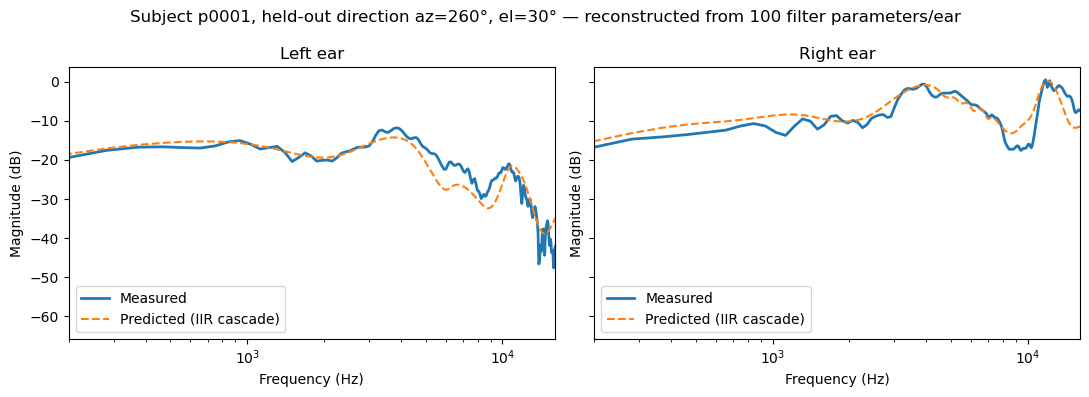

In [26]:
# One held-out direction: measured spectrum vs. the cascade reconstructed from predicted filter parameters
d = test_dir_idx[0]

with torch.no_grad():
    pred_db_np = predict_and_rendering(dir_feats_t[d:d + 1])[0].cpu().numpy()
true_db_np = target_db[d].cpu().numpy()

az_ex, el_ex, _ = positions[d]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ear, ax in enumerate(axes):
    ax.plot(freqs_hz, true_db_np[ear], label="Measured", linewidth=2)
    ax.plot(freqs_hz, pred_db_np[ear], label="Predicted (IIR cascade)", linestyle="--")
    ax.set_xscale("log")
    ax.set_xlim(200, 16000)
    ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Magnitude (dB)")
    ax.set_title(f"{'Left' if ear == 0 else 'Right'} ear")
    ax.legend(loc="lower left")
fig.suptitle(f"Subject {subject_id}, held-out direction az={az_ex:.0f}°, el={el_ex:.0f}° "
             f"— reconstructed from {n_params_per_ear} filter parameters/ear")
plt.tight_layout()
plt.show()


## 7. Compare against direct-magnitude field

The same subject, the same direction split, and the same SIREN trunk — the only difference is *what the network predicts*: raw magnitude bins vs. cascaded filter parameters. Counting what the field has to emit per direction is the first half of the comparison; it says nothing about accuracy, and nothing about inference cost either, since the cascade still has to be rendered to obtain a spectrum.



In [27]:
ratio = cfg["n_freq_bins"] / n_params_per_ear
print(f"NIIRF-style: {n_params_per_ear} filter parameters/ear -> reconstructs {cfg['n_freq_bins']} frequency bins")
print(f"Direct magnitude: predicts {cfg['n_freq_bins']} bins/ear directly, 1:1")
if ratio >= 1:
    print(f"Compression ratio: {ratio:.1f}x fewer numbers per ear with the filter parameterization")
else:
    print(f"Compression ratio: {1 / ratio:.1f}x MORE numbers per ear with the filter parameterization "
          f"(K={K} peaking filters outweigh {cfg['n_freq_bins']} magnitude bins)")


NIIRF-style: 100 filter parameters/ear -> reconstructs 257 frequency bins
Direct magnitude: predicts 257 bins/ear directly, 1:1
Compression ratio: 2.6x fewer numbers per ear with the filter parameterization


## 8. Head-to-head: training the direct-magnitude field

Section 7 only counted parameters. Here we train a neural field predicting the magnitude bins directly, where the last layer emits $2 \times 257$ dB bins instead of $2 \times 100$ filter parameters. Its targets are z-scored as in notebook 01, with statistics from the training directions only, so its loss curve is in normalized units and is not comparable to Section 5's; the comparison happens in dB, through the LSD of Section 6.



Training direct log-magnitude field:   1%|          | 5/500 [00:00<00:10, 45.93it/s, dev_loss=1.01, loss=1]

Training direct log-magnitude field: 100%|██████████| 500/500 [00:14<00:00, 35.02it/s, dev_loss=0.133, loss=0.0204]  


Restored checkpoint from epoch 122 (best dev loss = 0.0527)


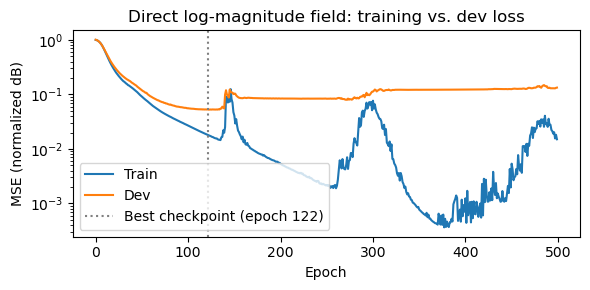

In [28]:
dims_direct = [2] + [cfg["hidden_dim"] for _ in range(cfg["n_layers"] - 1)] + [2 * cfg["n_freq_bins"]]
direct_field = build_siren(dims_direct, cfg["w0"]).to(device)

db_mean, db_std = target_db[train_dir_idx].mean(), target_db[train_dir_idx].std()
target_norm = (target_db - db_mean) / db_std


def predict_direct_db(dirs):
    """Directions [batch, 2] -> magnitude spectrum [batch, 2, n_freq_bins] in dB."""
    return direct_field(dirs).reshape(-1, 2, cfg["n_freq_bins"]) * db_std + db_mean


def direct_batch_loss(idx):
    pred = direct_field(dir_feats_t[idx]).reshape(-1, 2, cfg["n_freq_bins"])
    return nn.functional.mse_loss(pred, target_norm[idx])

direct_opt = torch.optim.RAdam(direct_field.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
direct_rng = np.random.default_rng(0)

direct_train_losses, direct_dev_losses = [], []
direct_best_dev, direct_best_epoch, direct_best_state = float("inf"), None, None

pbar = tqdm(range(cfg["n_epochs"]), desc="Training direct log-magnitude field")
for epoch in pbar:
    epoch_loss = 0.0
    shuffled = direct_rng.permutation(train_dir_idx)
    batches = np.array_split(shuffled, max(1, len(shuffled) // cfg["batch_size"]))
    for batch in batches:
        loss = direct_batch_loss(batch)
        direct_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(direct_field.parameters(), max_norm=cfg["clip"])
        direct_opt.step()
        epoch_loss += loss.item()
    direct_train_losses.append(epoch_loss / len(batches))

    with torch.no_grad():
        direct_dev_losses.append(direct_batch_loss(dev_dir_idx).item())

    if direct_dev_losses[-1] < direct_best_dev:
        direct_best_dev, direct_best_epoch = direct_dev_losses[-1], epoch
        direct_best_state = copy.deepcopy(direct_field.state_dict())

    if epoch % max(1, cfg["n_epochs"] // 20) == 0:
        pbar.set_postfix(loss=direct_train_losses[-1], dev_loss=direct_dev_losses[-1])

direct_field.load_state_dict(direct_best_state)
print(f"Restored checkpoint from epoch {direct_best_epoch} (best dev loss = {direct_best_dev:.4f})")

plt.figure(figsize=(6, 3))
plt.plot(direct_train_losses, label="Train")
plt.plot(direct_dev_losses, label="Dev")
plt.axvline(direct_best_epoch, color="gray", linestyle=":", label=f"Best checkpoint (epoch {direct_best_epoch})")
plt.xlabel("Epoch"); plt.ylabel("MSE (normalized dB)"); plt.yscale("log")
plt.title("Direct log-magnitude field: training vs. dev loss")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
def lsd_of(pred_fn, idx, band):
    with torch.no_grad():
        pred_db = pred_fn(dir_feats_t[idx])
    return torch.sqrt(torch.mean((target_db[idx][..., band] - pred_db[..., band]) ** 2, dim=-1)).cpu().numpy()


direct_train_lsd, direct_dev_lsd, direct_test_lsd = (
    lsd_of(predict_direct_db, idx, band) for idx in (train_dir_idx, dev_dir_idx, test_dir_idx)
)
assert direct_test_lsd.shape == test_lsd.shape, "both models must be scored on the same directions and ears"

print(f"{'Split':<12}{'NIIRF':>12}{'Direct':>12}")
for name, niirf, direct in [("Train", train_lsd, direct_train_lsd),
                            ("Dev", dev_lsd, direct_dev_lsd),
                            ("Test", test_lsd, direct_test_lsd)]:
    print(f"{name:<12}{niirf.mean():>9.2f} dB{direct.mean():>9.2f} dB")

n_params_direct = sum(p.numel() for p in direct_field.parameters())
print(f"\nOutputs per ear per direction: {n_params_per_ear} filter parameters vs. {cfg['n_freq_bins']} dB bins")
print(f"Network parameters: {n_params_field:,} (NIIRF) vs. {n_params_direct:,} (direct)")


Split              NIIRF      Direct
Train            4.09 dB     2.32 dB
Dev              4.85 dB     3.96 dB
Test             4.91 dB     3.79 dB

Outputs per ear per direction: 100 filter parameters vs. 257 dB bins
Network parameters: 629,448 (NIIRF) vs. 790,530 (direct)


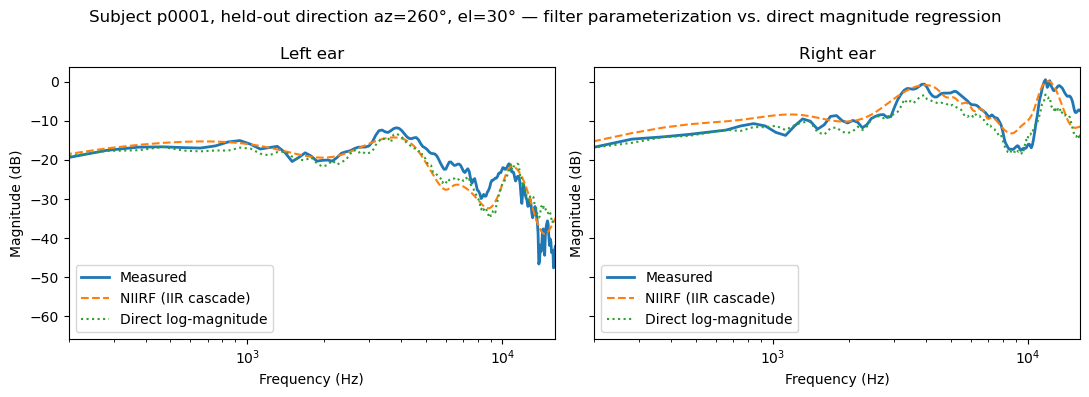

In [30]:
# Same held-out direction as Section 6, now with both models overlaid
with torch.no_grad():
    direct_db_np = predict_direct_db(dir_feats_t[d:d + 1])[0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ear, ax in enumerate(axes):
    ax.plot(freqs_hz, true_db_np[ear], label="Measured", linewidth=2)
    ax.plot(freqs_hz, pred_db_np[ear], label="NIIRF (IIR cascade)", linestyle="--")
    ax.plot(freqs_hz, direct_db_np[ear], label="Direct log-magnitude", linestyle=":")
    ax.set_xscale("log")
    ax.set_xlim(200, 16000)
    ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Magnitude (dB)")
    ax.set_title(f"{'Left' if ear == 0 else 'Right'} ear")
    ax.legend(loc="lower left")
fig.suptitle(f"Subject {subject_id}, held-out direction az={az_ex:.0f}°, el={el_ex:.0f}° "
             f"— filter parameterization vs. direct magnitude regression")
plt.tight_layout()
plt.show()


## Recap

- A neural field can predict *interpretable DSP parameters* — $(f_c, G)$ for the two shelf filters and $(f_c, G, f_b)$ for the $K$ peaking filters — and can be trained with a loss defined on the reconstructed magnitude spectrum
- The single subject is fitted from the measured directions and evaluated on unseen directions, i.e., spatial upsampling from sparse measurements
- On LSD, the direct-magnitude field of Section 8 comes out ahead here: the binding constraint is the cascade's approximation ceiling rather than the field that drives it, and a smaller LSD is not the reason to reach for this parameterization
- The reason to reach for it is that the filter parameters are inspectable, editable, and directly realizable as a biquad cascade, in ways a raw spectrum vector is not

**Next:** `03_upsampling_ranf.ipynb` — retrieval-augmented upsampling across the full subject pool.

